### Column Summary with Explanations

| **Category**            | **Column**                  | **Meaning**                                                                 |
|-------------------------|-----------------------------|-----------------------------------------------------------------------------|
| **Demographic**         | `State`                     | U.S. state of residence (e.g., Alabama).                                   |
|                         | `Sex`                       | Gender of respondent (e.g., Female, Male).                                |
|                         | `AgeCategory`               | Age group (e.g., Age 80 or older, Age 55 to 59).                          |
|                         | `RaceEthnicityCategory`     | Race/ethnicity (e.g., White only, Non-Hispanic).                          |
|                         | `HeightInMeters`            | Height in meters (used to calculate BMI).                                 |
|                         | `WeightInKilograms`         | Weight in kilograms (used to calculate BMI).                              |
|                         | `BMI`                       | Body Mass Index (weight/height²); high BMI indicates obesity risk.        |
| **Health Status**       | `GeneralHealth`             | Self-reported health (e.g., Very good, Poor).                             |
|                         | `PhysicalHealthDays`        | Days with poor physical health in past 30 days (numeric).                 |
|                         | `MentalHealthDays`          | Days with poor mental health in past 30 days (numeric).                   |
|                         | `LastCheckupTime`           | Time since last medical checkup (e.g., Within past year).                 |
| **Lifestyle**           | `PhysicalActivities`        | Engages in physical activities (Yes/No); lack of activity increases risk. |
|                         | `SleepHours`                | Average hours of sleep per night (numeric).                               |
|                         | `SmokerStatus`              | Smoking history (e.g., Never smoked, Current smoker); smoking is a major risk. |
|                         | `ECigaretteUsage`           | E-cigarette usage (e.g., Never used); related to smoking risk.            |
|                         | `AlcoholDrinkers`           | Consumes alcohol (Yes/No); excessive drinking is a risk factor.           |
|                         | `HighRiskLastYear`          | Engaged in high-risk behavior in past year (Yes/No).                      |
| **Medical History**     | `HadHeartAttack`            | Target variable: Had a heart attack (Yes/No).                             |
|                         | `HadAngina`                 | History of angina, chest pain from heart issues (Yes/No).                 |
|                         | `HadStroke`                 | History of stroke (Yes/No); linked to cardiovascular risk.                |
|                         | `HadAsthma`                 | History of asthma (Yes/No); may impact overall health.                    |
|                         | `HadSkinCancer`             | History of skin cancer (Yes/No).                                          |
|                         | `HadCOPD`                   | History of chronic obstructive pulmonary disease (Yes/No).                |
|                         | `HadDepressiveDisorder`     | History of depression (Yes/No); mental health impacts heart health.       |
|                         | `HadKidneyDisease`          | History of kidney disease (Yes/No); linked to heart disease risk.         |
|                         | `HadArthritis`              | History of arthritis (Yes/No); may indicate overall health decline.       |
|                         | `HadDiabetes`               | History of diabetes (Yes/No); a major heart disease risk factor.          |
| **Physical Limitations**| `DeafOrHardOfHearing`       | Hearing difficulty (Yes/No); indicates overall health.                    |
|                         | `BlindOrVisionDifficulty`   | Vision difficulty (Yes/No); indicates overall health.                     |
|                         | `DifficultyConcentrating`   | Difficulty concentrating (Yes/No); may reflect cognitive health.          |
|                         | `DifficultyWalking`         | Difficulty walking (Yes/No); indicates mobility issues.                   |
|                         | `DifficultyDressingBathing` | Difficulty dressing/bathing (Yes/No); indicates physical limitations.     |
|                         | `DifficultyErrands`         | Difficulty running errands (Yes/No); indicates functional limitations.    |
| **Medical Tests/Vacc.** | `ChestScan`                 | Had a chest scan (Yes/No); may indicate prior heart/lung checks.          |
|                         | `HIVTesting`                | Tested for HIV (Yes/No).                                                  |
|                         | `FluVaxLast12`              | Received flu vaccine in past 12 months (Yes/No).                          |
|                         | `PneumoVaxEver`             | Ever received pneumococcal vaccine (Yes/No).                              |
|                         | `TetanusLast10Tdap`         | Tetanus shot in past 10 years (e.g., Yes, received tetanus shot).         |
| **Other**               | `RemovedTeeth`              | Had teeth removed (Yes/No); may reflect overall health.                   |
|                         | `CovidPos`                  | Tested positive for COVID-19 (Yes/No); may impact heart health.           |

### Key Details
- **Target**: `HadHeartAttack` (binary: Yes/No) for heart disease prediction.
- **Important Features**: `AgeCategory`, `Sex`, `BMI`, `SmokerStatus`, `HadDiabetes`, `PhysicalActivities` (key heart disease risk factors).
- **Source**: CDC BRFSS 2022 survey; reduced from 300 to 40 variables. See processing details: [data_processing.ipynb](https://github.com/kamilpytlak/data-science-projects/blob/main/heart-disease-prediction/2022/notebooks/data_processing.ipynb).
- **Applications**: EDA, machine learning (e.g., SVC, Logistic Regression) to predict heart disease, addressing class imbalance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

df = pd.read_csv( 'heart_2022_with_nans.csv' )


In [2]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445127,Virgin Islands,Female,Good,0.0,3.0,Within past 2 years (1 year but less than 2 ye...,Yes,6.0,None of them,No,...,1.65,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes
445128,Virgin Islands,Female,Excellent,2.0,2.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.70,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
445129,Virgin Islands,Female,Poor,30.0,30.0,5 or more years ago,No,5.0,1 to 5,No,...,1.70,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
445130,Virgin Islands,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,5.0,None of them,Yes,...,1.83,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes


In [3]:
df.shape

(445132, 40)

# Análise dos valores faltantes

In [4]:
df.isna().sum()

State                            0
Sex                              0
GeneralHealth                 1198
PhysicalHealthDays           10927
MentalHealthDays              9067
LastCheckupTime               8308
PhysicalActivities            1093
SleepHours                    5453
RemovedTeeth                 11360
HadHeartAttack                3065
HadAngina                     4405
HadStroke                     1557
HadAsthma                     1773
HadSkinCancer                 3143
HadCOPD                       2219
HadDepressiveDisorder         2812
HadKidneyDisease              1926
HadArthritis                  2633
HadDiabetes                   1087
DeafOrHardOfHearing          20647
BlindOrVisionDifficulty      21564
DifficultyConcentrating      24240
DifficultyWalking            24012
DifficultyDressingBathing    23915
DifficultyErrands            25656
SmokerStatus                 35462
ECigaretteUsage              35660
ChestScan                    56046
RaceEthnicityCategor

In [5]:
#vamos verificar as variáveis numéricas do dataset
print( df.select_dtypes( include = [ 'number' ] ).columns.tolist() )

['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'HeightInMeters', 'WeightInKilograms', 'BMI']


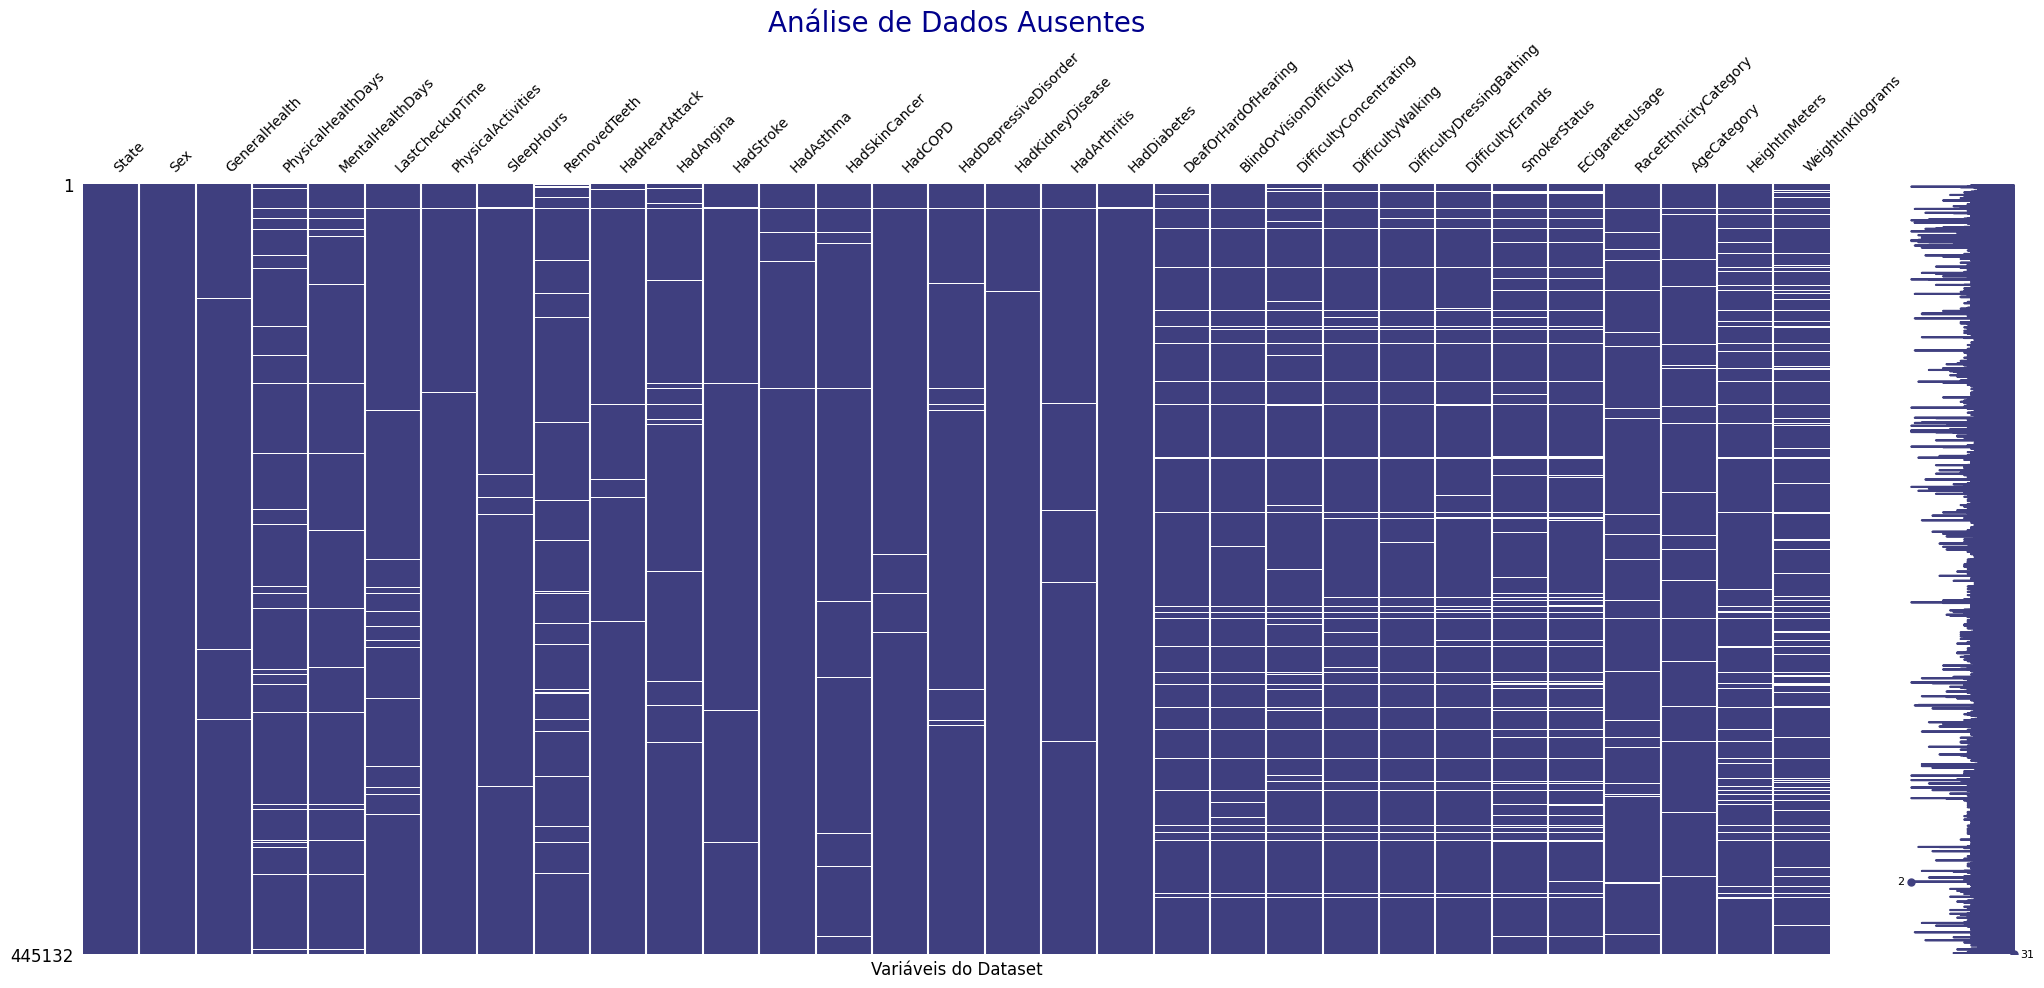

In [6]:
ax = msno.matrix( df, filter = 'top', p = 0.9, color = ( 0.25, 0.25, 0.5 ), fontsize = 10 )

ax.set_title( "Análise de Dados Ausentes", fontsize = 20, color = 'darkblue' )
ax.set_xlabel( "Variáveis do Dataset", fontsize = 12 )
plt.show()

In [7]:
null_series = df.isnull().mean() * 100

above_15 = null_series[ null_series > 15 ].index.tolist()

print( null_series.sort_values( ascending = True ) )


State                         0.000000
Sex                           0.000000
HadDiabetes                   0.244197
PhysicalActivities            0.245545
GeneralHealth                 0.269134
HadStroke                     0.349784
HadAsthma                     0.398309
HadKidneyDisease              0.432681
HadCOPD                       0.498504
HadArthritis                  0.591510
HadDepressiveDisorder         0.631723
HadHeartAttack                0.688560
HadSkinCancer                 0.706083
HadAngina                     0.989594
SleepHours                    1.225030
LastCheckupTime               1.866413
MentalHealthDays              2.036924
AgeCategory                   2.039620
PhysicalHealthDays            2.454777
RemovedTeeth                  2.552052
RaceEthnicityCategory         3.157940
DeafOrHardOfHearing           4.638399
BlindOrVisionDifficulty       4.844406
DifficultyDressingBathing     5.372564
DifficultyWalking             5.394355
DifficultyConcentrating  

Vamos checar se há duplicatas no nosso dataset. Caso haja, vamos dropa-las

In [8]:
df.duplicated().sum()


np.int64(157)

In [9]:
#como parece que temos alguns valores duplicados, vamos tentar analisar se são erros de duplicata mesmo ou se são observaçoẽs válidas
duplicatas = df[ df.duplicated( keep = False ) ].sort_values( by = list( df.columns ) )
duplicatas

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
4712,Alaska,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7310,Alaska,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10696,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.7,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
11503,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.7,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
32137,California,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431351,Wisconsin,Male,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
423677,Wisconsin,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
427638,Wisconsin,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
433340,Wyoming,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
#como de fato parece que são todas informações redundantes decidimos por dropar essas observações
df = df.drop_duplicates()

Primeiro, vamos avaliar novamente a quantidade de valores nulos em cada uma das variáveis categóricas

In [11]:
nominal_cols = df.select_dtypes( include = [ 'object', 'category' ] ).columns.tolist()

print( ( df[ nominal_cols ].isnull().mean() * 100 ).sort_values( ascending = False ) )

TetanusLast10Tdap            18.511152
PneumoVaxEver                17.280521
HIVTesting                   14.828024
ChestScan                    12.562504
CovidPos                     11.375471
HighRiskLastYear             11.343783
FluVaxLast12                 10.556773
AlcoholDrinkers              10.433845
ECigaretteUsage               7.981123
SmokerStatus                  7.936626
DifficultyErrands             5.733131
DifficultyConcentrating       5.414911
DifficultyWalking             5.363672
DifficultyDressingBathing     5.341873
BlindOrVisionDifficulty       4.813529
DeafOrHardOfHearing           4.607450
RaceEthnicityCategory         3.157031
RemovedTeeth                  2.551829
AgeCategory                   2.038092
LastCheckupTime               1.865498
HadAngina                     0.988820
HadSkinCancer                 0.705208
HadHeartAttack                0.687679
HadDepressiveDisorder         0.630822
HadArthritis                  0.590595
HadCOPD                  

/tmp/ipykernel_60680/3538802792.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  nominal_cols = df.select_dtypes( include = [ 'object', 'category' ] ).columns.tolist()


Veja que a variável que checa se recebeu vacina de tetano faria com que a gente perdesse 18% dos dados ao dropar as observações faltantes. Nesse caso essa variável não parece ser muito importante para os próximos eixos, então decidimos por dropar essa variável ao invés de suas observações 


In [12]:
df = df.drop( columns = [ 'TetanusLast10Tdap' ] )

As outras variáveis que também tem uma grande quantidade de dados faltantes como o fato de ter tomado vacina de pneumonia ou entao o fato de ter hiv parecem ter uma importância para analisar o risco de ataque cardíaco, podemos inclusive fazer uma análise de agrupamento mais adiante (podemos agrupar pessoas que têm muitos dados unknown e não fazem checkup, poderiamos tentar achar um cluster de pacientes que "não se importam com a saúde" para avaliar o risco)

Uma abordagem que decidimos tomar é : se tivermos mais que 10% dos dados faltantes em variáveis categóricas, preencheremos esses dados com 'unknown', após isso prosseguiremos com uma análise exclusiva para esses tipos de dados. Caso tenha menos que 10% de dados faltantes, droparemos as observações.

In [13]:
cat_cols = df.select_dtypes( include = [ 'object', 'category' ] ).columns

null_vars = df[ cat_cols ].isnull().mean() * 100
cols_to_fix = null_vars[ null_vars > 10 ].index

for col in cols_to_fix:
    df[ col ] = df[ col ].fillna( 'Unknown' )

df = df.dropna( subset = cat_cols )

/tmp/ipykernel_60680/3729776358.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes( include = [ 'object', 'category' ] ).columns


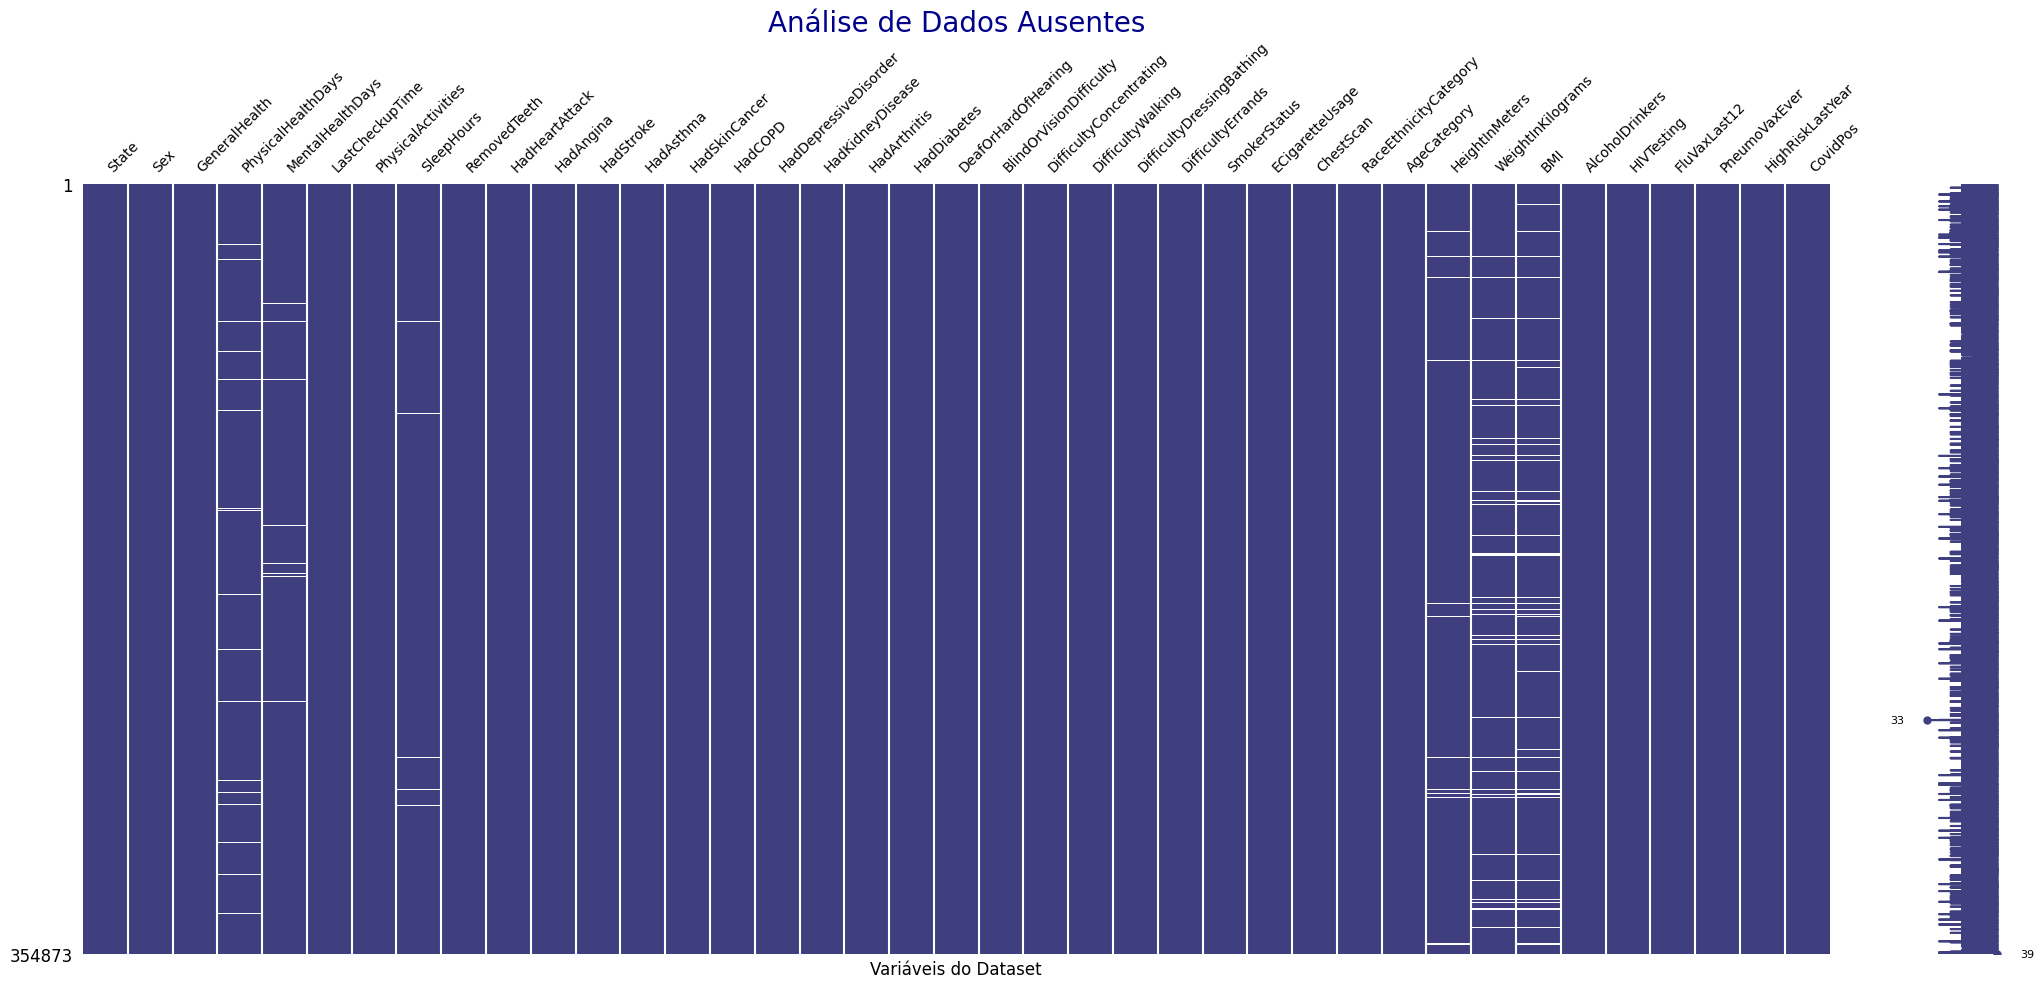

In [14]:
ax = msno.matrix( df, filter = 'top', p = 0.9, color = ( 0.25, 0.25, 0.5 ), fontsize = 10 )

ax.set_title( "Análise de Dados Ausentes", fontsize = 20, color = 'darkblue' )
ax.set_xlabel( "Variáveis do Dataset", fontsize = 12 )
plt.show()

Agora, vamos fazer a imputação dos dados nas variáveis contínuas. Como BMI, peso e altura são as quantitativas com mais dados faltantes(10.96, 9.45, 6.43 respectivamente), vamos tomar um cuidado específico na imputação delas. Para isso, vamos fazer o seguinte: 

- Imputação Estratificada: Preencheremos WeightInKilograms e HeightInMeters utilizando a mediana agrupada por Sex e AgeCategory, garantindo que os valores reflitam o perfil biológico específico de cada grupo.

- Consistência Algébrica: Recalcularemos o BMI através da fórmula Weight/Height^2 para todas as observações onde os componentes foram imputados, mantendo a relação física exata entre as variáveis.

In [15]:
# imputação por grupos
for col in [ 'WeightInKilograms', 'HeightInMeters' ]:
    df[ col ] = df[ col ].fillna( df.groupby( [ 'Sex', 'AgeCategory' ] )[ col ].transform( 'median' ) )

#recálculo do BMI (consistência algébrica)
#só recalculamos onde o BMI ainda for nulo

mask_recalc = df[ 'BMI' ].isnull()
df.loc[ mask_recalc, 'BMI' ] = df[ 'WeightInKilograms' ] / ( df[ 'HeightInMeters' ] ** 2 )

In [16]:
#preenchendo com a mediana o resto das quantitavas (mais robusta a outliers que a média)
quant_cols = [ 'PhysicalHealthDays', 'MentalHealthDays', 'SleepHours' ]

df[ quant_cols ] = df[ quant_cols ].fillna( df[ quant_cols ].median() )

In [17]:
#vamos preencher as ordinais com a moda
ordinal_cols = [ 'GeneralHealth', 'AgeCategory' ]
df[ ordinal_cols ] = df[ ordinal_cols ].fillna( df[ ordinal_cols ].mode().iloc[ 0 ] )

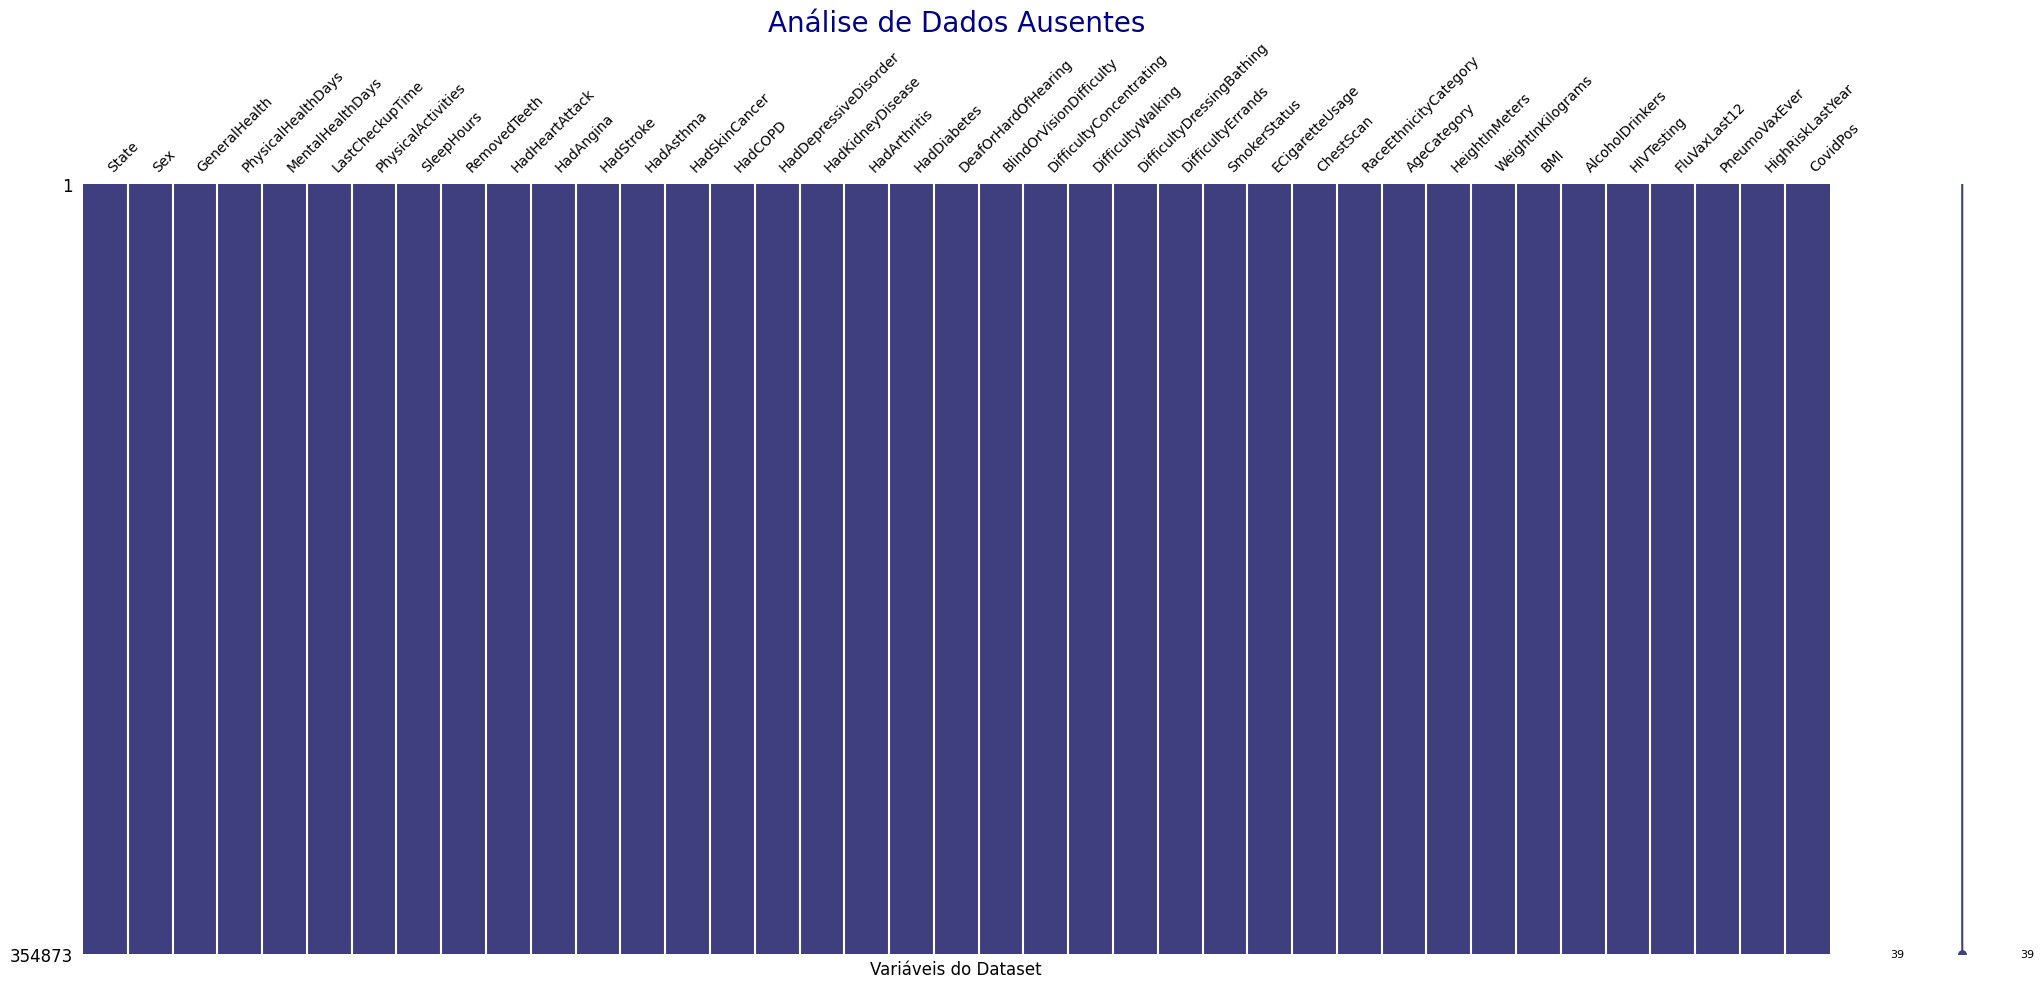

In [18]:
ax = msno.matrix( df, filter = 'top', p = 0.9, color = ( 0.25, 0.25, 0.5 ), fontsize = 10 )

ax.set_title( "Análise de Dados Ausentes", fontsize = 20, color = 'darkblue' )
ax.set_xlabel( "Variáveis do Dataset", fontsize = 12 )
plt.show()

Ótimo, não temos mais valores faltantes

# Análise de outliers

# MCA (PCA para variáveis discretas)